# EDA — `transactions` (June 2026): can transactions tell us who is delinquent?

**Where we left off.** `products.csv` and `customers.csv` showed a sizeable delinquent credit book
(18,765 products, 17,650 customers) but **no signal** in any static attribute, and no payment
target. Transactions are the first dataset with *behaviour* (purchases, withdrawals, and a
`Payment` type), so they are the first real chance for a signal.

**Questions.**

1. Does the transaction file join cleanly to products and customers, and is it trustworthy?
2. Does it contain something usable as a payment / time-to-payment record?
3. Does June behaviour differ between delinquent and non-delinquent products/customers?
4. Does it resolve the earlier "no FX rates" limitation?

Scope: **only `year=2026/month=06`**, descriptive analysis, no model. Nothing is imputed or
invented. Delinquency labels come from the `products.csv` snapshot (`days_past_due`).

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIRECTORY = REPO_ROOT / "data" / "data"
TRANSACTIONS_DIRECTORY = REPO_ROOT / "data" / "transactions" / "year=2026" / "month=06"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"

partition_files = sorted(TRANSACTIONS_DIRECTORY.glob("day=*/transactions_*.csv"))
transactions = pd.concat(
    (
        pd.read_csv(path, dtype={"response_code": str}, parse_dates=["transaction_date", "process_date"])
        for path in partition_files
    ),
    ignore_index=True,
)
products = pd.read_csv(
    DATA_DIRECTORY / "products.csv",
    parse_dates=["opening_date", "expiration_date", "last_transaction_date", "last_updated"],
)
customers = pd.read_csv(DATA_DIRECTORY / "customers.csv", usecols=["customer_id", "country", "segment"])
REFERENCE_DATE = products["last_transaction_date"].max().normalize()

display(pd.Series({
    "daily files": len(partition_files),
    "transactions": len(transactions),
    "first transaction_date": transactions["transaction_date"].min(),
    "last transaction_date": transactions["transaction_date"].max(),
    "REFERENCE_DATE used in products/customers notebooks": REFERENCE_DATE,
}, name="value").to_frame())

,value
daily files,17
transactions,70691
first transaction_date,2026-06-01 06:00:29
last transaction_date,2026-06-18 05:59:41
REFERENCE_DATE used in products/customers notebooks,2026-06-17 00:00:00


The window is **1-17 June 2026** (business days: raw timestamps run from 2026-06-01 06:00 to
2026-06-18 05:59 because the day cuts over at 06:00), and it ends on the same date we used as the
snapshot proxy for `products.csv` (2026-06-17). So the transaction window and the delinquency labels are
contemporaneous: this can show whether behaviour *differs* between delinquent and current
products, not whether it *predicts* later delinquency.

## 2. Structure and data quality

In [2]:
schema = pd.DataFrame({
    "dtype": transactions.dtypes.astype(str),
    "missing_pct": transactions.isna().mean() * 100,
    "distinct": transactions.nunique(),
})
display(schema)
for column in ["transaction_type", "transaction_status", "channel", "currency", "transaction_country"]:
    display(transactions[column].value_counts(dropna=False).to_frame(column))
display(pd.crosstab(transactions["transaction_status"], transactions["response_code"].fillna("none")))

,dtype,missing_pct,distinct
transaction_id,str,0.00,70691
transaction_date,datetime64[us],0.00,68958
process_date,datetime64[us],0.00,17
product_id,str,0.00,63699
customer_id,str,0.00,51950
transaction_type,str,0.00,6
transaction_category,str,61.27,6
amount,float64,0.00,66591
currency,str,0.00,3
amount_usd,float64,57.27,27624


,transaction_type
transaction_type,
Purchase,16989
Withdrawal,15588
Transfer,14310
Payment,11852
Deposit,9859
Adjustment,2093


,transaction_status
transaction_status,
Approved,64984
Declined,3557
Pending,1445
Reversed,705


,channel
channel,
POS,24873
ATM,21055
Web,10606
App,10562
Branch,2172
Transfer,1423


,currency
currency,
USD,38900
COP,19118
ARS,12673


,transaction_country
transaction_country,
México,33677
Colombia,20671
Argentina,13887
Mexico,633
Brazil,628
USA,603
Spain,592


response_code,00,05,14,51,54,none
transaction_status,,,,,,
Approved,61782,0,0,0,0,3202
Declined,0,830,846,877,840,164
Pending,0,318,348,346,355,78
Reversed,0,178,163,166,167,31


Statuses and response codes are perfectly linked (`Approved` is always `00`; the four failure
codes are spread evenly over `Declined`/`Pending`/`Reversed`), and the failure rates are the same
~8% for every transaction type, which is what random assignment looks like. Some countries appear
as both `México` and `Mexico`.

In [3]:
transactions_with_product = transactions.merge(
    products, on="product_id", how="left", suffixes=("", "_product"), validate="many_to_one", indicator=True
)
transaction_day = transactions_with_product["transaction_date"].dt.normalize()

display(pd.Series({
    "duplicate transaction_id": transactions["transaction_id"].duplicated().sum(),
    "transactions whose product_id is not in products.csv": (transactions_with_product["_merge"] != "both").sum(),
    "transactions whose customer_id differs from the product owner":
        (transactions_with_product["customer_id"] != transactions_with_product["customer_id_product"]).sum(),
    "transactions whose currency differs from the product currency":
        (transactions_with_product["currency"] != transactions_with_product["currency_product"]).sum(),
    "transactions whose customer_id is not in customers.csv": (~transactions["customer_id"].isin(customers["customer_id"])).sum(),
    "transactions dated before the product's opening_date": (transaction_day < transactions_with_product["opening_date"]).sum(),
    "process_date earlier than transaction date": (transactions["process_date"] < transaction_day).sum(),
    "process_date later than transaction date": (transactions["process_date"] > transaction_day).sum(),
    "products' last_transaction_date is older than a June transaction on the same product":
        (transactions_with_product["last_transaction_date"] < transactions_with_product["transaction_date"]).sum(),
    "transactions on products whose status is not Active":
        (transactions_with_product["product_status"] != "Active").sum(),
}, name="count").to_frame())
display(pd.crosstab(transactions_with_product["product_status"], transactions_with_product["transaction_type"]))

,count
duplicate transaction_id,0
transactions whose product_id is not in products.csv,0
transactions whose customer_id differs from the product owner,0
transactions whose currency differs from the product currency,0
transactions whose customer_id is not in customers.csv,0
transactions dated before the product's opening_date,204
process_date earlier than transaction date,17702
process_date later than transaction date,0
products' last_transaction_date is older than a June transaction on the same product,62414
transactions on products whose status is not Active,0


transaction_type,Adjustment,Deposit,Payment,Purchase,Transfer,Withdrawal
product_status,,,,,,
Active,2093,9859,11852,16989,14310,15588


The joins are clean: no orphan products or customers, and customer and currency always agree with
the product. But `products.last_transaction_date` is **older than a June transaction on the same
product** for most rows, so that column of `products.csv` is stale or unrelated to this file.
Only `Active` products ever transact; `Closed`, `Blocked` and `Suspended` products have none.
That matters for comparisons: all analysis below on delinquency is restricted to `Active` credit
products, otherwise the missing activity of inactive products would look like a signal.

`process_date` is earlier than the timestamp's calendar date on 25% of rows. That is a business-day
convention, not an error: every such row falls between 00:00 and 05:59, i.e. `process_date` =
`(timestamp - 6 hours).date` (also confirmed over the full history in `transactions_history.ipynb`).

## 3. FX: the file implies exchange rates

`amount_usd` is filled for ARS and COP rows and empty for USD rows. Dividing `amount` by
`amount_usd` recovers the rate the data was generated with. If it is (nearly) constant it can serve
as an explicit, data-derived rate, which closes the earlier gap where sums across currencies were
impossible.

In [4]:
recorded_usd = transactions[transactions["amount_usd"].notna()].assign(
    implied_units_per_usd=lambda t: t["amount"] / t["amount_usd"]
)
display(recorded_usd.groupby("currency")["implied_units_per_usd"].describe())
display(transactions.groupby("currency")["amount_usd"].apply(lambda s: s.notna().mean() * 100).to_frame("amount_usd_present_pct"))

IMPLIED_UNITS_PER_USD = recorded_usd.groupby("currency")["implied_units_per_usd"].median().to_dict()
IMPLIED_UNITS_PER_USD["USD"] = 1.0
IMPLIED_UNITS_PER_USD

,count,mean,std,min,25%,50%,75%,max
currency,,,,,,,,
ARS,"12,034.00",350.00,0.01,349.70,350.00,350.00,350.00,350.19
COP,"18,169.00","4,000.00",0.13,"3,997.13","3,999.99","4,000.00","4,000.01","4,003.27"


,amount_usd_present_pct
currency,
ARS,94.96
COP,95.04
USD,0.00


{'ARS': 350.0, 'COP': 3999.9998601859884, 'USD': 1.0}

The implied rate is essentially fixed for the whole window (spread far below 0.1%). Daily median rates are identical
day by day. That is not how real FX behaves, which is one more sign of generated data, but it is a
**usable, data-derived conversion** for this dataset. It is used below and clearly labelled
"USD-equivalent at the implied rate". Rows where `amount_usd` is missing for ARS/COP are converted
with the same rate, not left out.

In [5]:
transactions["amount_usd_equivalent"] = transactions["amount"] / transactions["currency"].map(IMPLIED_UNITS_PER_USD)
transactions_with_product["amount_usd_equivalent"] = transactions["amount_usd_equivalent"]
recorded_rows = transactions["amount_usd"].notna()
display(pd.Series({
    "max relative gap, recorded amount_usd vs amount / implied rate":
        ((transactions.loc[recorded_rows, "amount_usd_equivalent"] / transactions.loc[recorded_rows, "amount_usd"]) - 1).abs().max(),
    "ARS/COP rows converted with the implied rate (amount_usd missing)":
        (~recorded_rows & (transactions["currency"] != "USD")).sum(),
}, name="value").to_frame())

,value
"max relative gap, recorded amount_usd vs amount / implied rate",0.00
ARS/COP rows converted with the implied rate (amount_usd missing),"1,588.00"


### Delinquent exposure in one currency (re-sizing the earlier result)

With the implied rates, the delinquent balance from `products.csv` can be expressed in a single
unit. Caveats from before still apply: it is the **total balance** on delinquent products, not the
overdue amount.

In [6]:
credit = products[products["days_past_due"].notna()].copy()
credit["is_delinquent"] = credit["days_past_due"] > 0
credit["balance_usd_equivalent"] = credit["current_balance"] / credit["currency"].map(IMPLIED_UNITS_PER_USD)

exposure_usd = credit.groupby("is_delinquent").agg(
    products=("product_id", "size"),
    balance_usd_equivalent=("balance_usd_equivalent", "sum"),
)
exposure_usd["share_of_credit_balance_pct"] = exposure_usd["balance_usd_equivalent"] / exposure_usd["balance_usd_equivalent"].sum() * 100
display(exposure_usd)

active_delinquent = credit[credit["is_delinquent"] & (credit["product_status"] == "Active")]
display(active_delinquent.groupby("currency")["balance_usd_equivalent"].sum().to_frame("active_delinquent_usd_equivalent").assign(
    total=lambda t: t["active_delinquent_usd_equivalent"].sum()
))

,products,balance_usd_equivalent,share_of_credit_balance_pct
is_delinquent,,,
False,106585,"1,018,636,205.30",84.86
True,18765,"181,790,828.73",15.14


,active_delinquent_usd_equivalent,total
currency,,
ARS,"27,518,162.86","153,948,327.07"
COP,"40,116,847.24","153,948,327.07"
USD,"86,313,316.96","153,948,327.07"


## 4. Is there a payment record in here?

A `Payment` transaction type exists, so it is the obvious candidate for a payment ledger. Two
questions decide whether it is usable: **which products get payments**, and **do payment sizes have any relation to what is owed**.

In [7]:
display(pd.crosstab(transactions_with_product["product_type"], transactions_with_product["transaction_type"], margins=True))
display(transactions_with_product.groupby("transaction_type")["merchant_name"].apply(lambda s: s.notna().mean() * 100).to_frame("with_merchant_pct"))

transaction_type,Adjustment,Deposit,Payment,Purchase,Transfer,Withdrawal,All
product_type,,,,,,,
Cuenta Ahorro,0,5454,2161,0,7384,6454,21453
Cuenta Corriente,0,4405,1732,0,6207,5288,17632
Inversión,317,0,635,0,99,0,1051
Préstamo Hipotecario,630,0,1257,0,205,0,2092
Préstamo Personal,1042,0,2172,0,382,0,3596
Seguro,104,0,243,0,33,0,380
Tarjeta Crédito,0,0,2583,12235,0,2763,17581
Tarjeta Débito,0,0,1069,4754,0,1083,6906
All,2093,9859,11852,16989,14310,15588,70691


,with_merchant_pct
transaction_type,
Adjustment,0.00
Deposit,0.00
Payment,0.00
Purchase,95.17
Transfer,0.00
Withdrawal,0.00


`Payment` appears on **every product type**, including savings, checking, debit cards and
investments, which cannot be repaid. So `Payment` is not "repayment of a credit obligation". It is a
generic transaction label. Purchases exist only on cards, withdrawals only on cards and deposit accounts, and personal
loans and mortgages have only `Payment`, `Transfer` and `Adjustment`.

In [8]:
credit_activity = transactions_with_product[transactions_with_product["days_past_due"].notna()].copy()
credit_activity["balance_usd_equivalent"] = (
    credit_activity["current_balance"] / credit_activity["currency_product"].map(IMPLIED_UNITS_PER_USD)
)
approved_credit_payments = credit_activity[
    (credit_activity["transaction_type"] == "Payment") & (credit_activity["transaction_status"] == "Approved")
]
display(approved_credit_payments.groupby("product_type")["amount_usd_equivalent"].describe())
payment_to_balance = approved_credit_payments["amount_usd_equivalent"] / approved_credit_payments["balance_usd_equivalent"]
display(payment_to_balance.replace([float("inf")], float("nan")).describe(percentiles=[0.1, 0.5, 0.9]).to_frame("payment / current_balance"))
display(approved_credit_payments.groupby("product_type")[["amount_usd_equivalent", "balance_usd_equivalent"]].corr(method="spearman").xs("amount_usd_equivalent", level=1)["balance_usd_equivalent"].to_frame("spearman payment vs balance"))

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Préstamo Hipotecario,"1,102.00","1,050.91",566.09,50.24,553.97,"1,083.68","1,524.24","1,999.11"
Préstamo Personal,"1,874.00","1,028.04",570.49,50.80,517.63,"1,030.31","1,530.46","1,998.92"
Tarjeta Crédito,"2,270.00","1,030.66",569.13,51.74,536.94,"1,033.62","1,528.86","1,999.59"


,payment / current_balance
count,"5,129.00"
mean,0.69
std,6.21
min,0.00
10%,0.01
50%,0.18
90%,1.19
max,381.55


,spearman payment vs balance
product_type,
Préstamo Hipotecario,-0.04
Préstamo Personal,-0.02
Tarjeta Crédito,0.01


Payment amounts are bounded between roughly 50 and 2,000 USD-equivalent for every product type,
whatever the balance. Mortgage payments are no larger than card payments. There is no sign that a
payment is tied to an instalment or to an amount due, and no due date exists. So `Payment` rows do not
constitute a repayment ledger, and we should treat them with caution as a "payment behaviour"
proxy at best.

## 5. Does June behaviour differ between delinquent and current products?

Scope: `Active` credit products with a known `days_past_due` (the only ones that can transact).
Per-product behaviour features are counts over the 17-day window; a product with no rows is a
product with **zero recorded transactions** in that window, which is a real absence of activity,
not a missing value. 95% intervals are simple binomial half-widths, only to show what is noise.

In [9]:
transactions["is_approved_payment"] = (transactions["transaction_type"] == "Payment") & (transactions["transaction_status"] == "Approved")
transactions["is_declined"] = transactions["transaction_status"] == "Declined"
transactions["is_purchase"] = transactions["transaction_type"] == "Purchase"
transactions["is_withdrawal"] = transactions["transaction_type"] == "Withdrawal"
transactions["payment_usd_equivalent"] = transactions["amount_usd_equivalent"].where(transactions["is_approved_payment"], 0.0)

product_activity = transactions.groupby("product_id").agg(
    transactions_in_window=("transaction_id", "size"),
    approved_payments=("is_approved_payment", "sum"),
    declined=("is_declined", "sum"),
    purchases=("is_purchase", "sum"),
    withdrawals=("is_withdrawal", "sum"),
    payment_usd_equivalent=("payment_usd_equivalent", "sum"),
    last_transaction_date=("transaction_date", "max"),
)
first_payment_date = (
    transactions[transactions["is_approved_payment"]].groupby("product_id")["transaction_date"].min().rename("first_payment_date")
)

active_credit = (
    credit[credit["product_status"] == "Active"]
    .merge(product_activity.drop(columns="last_transaction_date"), on="product_id", how="left", suffixes=("", "_window"))
    .merge(first_payment_date, on="product_id", how="left")
)
count_columns = ["transactions_in_window", "approved_payments", "declined", "purchases", "withdrawals", "payment_usd_equivalent"]
active_credit[count_columns] = active_credit[count_columns].fillna(0)
active_credit = active_credit.merge(
    product_activity["last_transaction_date"].rename("last_window_transaction"), on="product_id", how="left"
)
active_credit["days_since_last_window_transaction"] = (REFERENCE_DATE - active_credit["last_window_transaction"].dt.normalize()).dt.days

display(pd.Series({
    "Active credit products": len(active_credit),
    "  of which delinquent": active_credit["is_delinquent"].sum(),
    "  delinquent rate (%)": active_credit["is_delinquent"].mean() * 100,
    "with at least one transaction in the window": (active_credit["transactions_in_window"] > 0).sum(),
    "  as % of Active credit products": (active_credit["transactions_in_window"] > 0).mean() * 100,
}, name="value").to_frame())

,value
Active credit products,"106,596.00"
of which delinquent,"15,889.00"
delinquent rate (%),14.91
with at least one transaction in the window,"19,985.00"
as % of Active credit products,18.75


In [10]:
def delinquency_rate_by_segment(frame: pd.DataFrame, flag_column: str, segment: pd.Series, label: str) -> pd.DataFrame:
    """Computes the delinquency rate and its 95% binomial half-width for each segment of one feature.

    Exists so every behaviour feature is compared on identical terms, with noise made visible.

    Args:
        frame: Rows carrying the boolean delinquency flag.
        flag_column: Name of the boolean delinquency column in frame.
        segment: Segment assignment aligned to frame's index.
        label: Feature name shown in the output.

    Returns:
        pd.DataFrame: one row per segment with feature, segment, rows, delinquent rate (%) and half-width (%).
    """
    grouped = frame[flag_column].groupby(segment, observed=True).agg(["mean", "size"])
    half_width = 1.96 * (grouped["mean"] * (1 - grouped["mean"]) / grouped["size"]) ** 0.5
    return pd.DataFrame({
        "feature": label,
        "segment": grouped.index.astype(str),
        "rows": grouped["size"].to_numpy(),
        "delinquent_rate_pct": grouped["mean"].to_numpy() * 100,
        "ci_half_width_pct": half_width.to_numpy() * 100,
    })


def bucket_count(counts: pd.Series, cap: int) -> pd.Series:
    """Caps a count so rare high values collapse into a single '<cap>+' segment.

    Exists to keep segments large enough to be readable.

    Args:
        counts: Non-negative integer counts.
        cap: Value at and above which counts are merged.

    Returns:
        pd.Series: string labels such as '0', '1', '2+'.
    """
    return counts.clip(upper=cap).astype(int).astype(str).where(counts < cap, f"{cap}+")


paid_ratio = active_credit["payment_usd_equivalent"] / active_credit["balance_usd_equivalent"].where(
    active_credit["balance_usd_equivalent"] > 0
)
product_segments = {
    "transactions in window": bucket_count(active_credit["transactions_in_window"], 3),
    "approved payments": bucket_count(active_credit["approved_payments"], 2),
    "declined transactions": bucket_count(active_credit["declined"], 1),
    "purchases": bucket_count(active_credit["purchases"], 2),
    "withdrawals": bucket_count(active_credit["withdrawals"], 1),
    "days since last transaction": pd.cut(
        active_credit["days_since_last_window_transaction"], [-1, 5, 11, 17], labels=["0-5", "6-11", "12-17"]
    ).astype(str).where(active_credit["last_window_transaction"].notna(), "no transaction"),
    "paid / balance (payers only)": pd.cut(paid_ratio[active_credit["approved_payments"] > 0], [0, 0.0001, 0.001, 0.01, float("inf")]).astype(str),
    "product_type": active_credit["product_type"],
}
product_rates = pd.concat(
    [delinquency_rate_by_segment(active_credit.loc[values.index], "is_delinquent", values, name)
     for name, values in product_segments.items()],
    ignore_index=True,
)
product_base_rate = active_credit["is_delinquent"].mean() * 100
display(product_rates)

,feature,segment,rows,delinquent_rate_pct,ci_half_width_pct
0,transactions in window,0,86611,14.99,0.24
1,transactions in window,1,17992,14.47,0.51
2,transactions in window,2,1864,15.34,1.64
3,transactions in window,3+,129,12.40,5.69
4,approved payments,0,101535,14.95,0.22
5,approved payments,1,4882,14.11,0.98
6,approved payments,2+,179,9.50,4.29
7,declined transactions,0,105492,14.90,0.21
8,declined transactions,1+,1104,15.31,2.12
9,purchases,0,95779,14.91,0.23


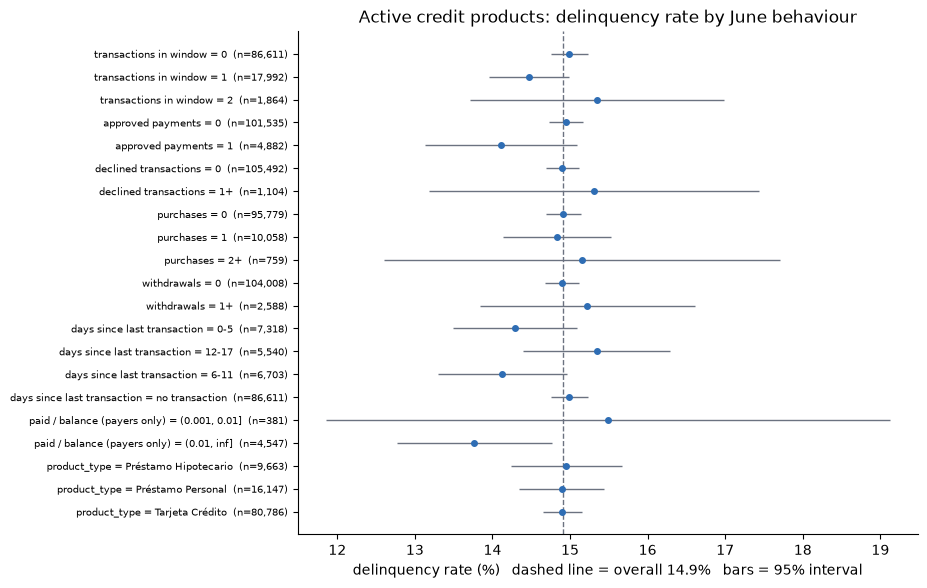

In [11]:
def plot_rates_against_base(rates: pd.DataFrame, base_rate: float, title: str, minimum_rows: int) -> None:
    """Draws a dot plot of segment delinquency rates with 95% intervals against the overall rate.

    Exists so that behaviour features can be judged visually against the overall rate and their noise.

    Args:
        rates: Output of delinquency_rate_by_segment concatenated across features.
        base_rate: Overall delinquency rate (%) drawn as the dashed reference line.
        title: Chart title.
        minimum_rows: Segments with fewer rows are left out as too noisy to read.

    Returns:
        None: the chart is shown.
    """
    frame = rates[rates["rows"] >= minimum_rows].iloc[::-1].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8, 0.24 * len(frame) + 1.5))
    ax.axvline(base_rate, color=MUTED_COLOR, linewidth=1, linestyle="--")
    ax.errorbar(frame["delinquent_rate_pct"], frame.index, xerr=frame["ci_half_width_pct"], fmt="o",
                color=BAR_COLOR, ecolor=MUTED_COLOR, elinewidth=1, markersize=4, zorder=3)
    ax.set_yticks(frame.index)
    ax.set_yticklabels(frame["feature"] + " = " + frame["segment"] + "  (n=" + frame["rows"].map("{:,}".format) + ")", fontsize=7)
    ax.set_xlabel(f"delinquency rate (%)   dashed line = overall {base_rate:.1f}%   bars = 95% interval")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()


plot_rates_against_base(product_rates, product_base_rate, "Active credit products: delinquency rate by June behaviour", 300)

### By aging level: activity and payments

If delinquent products behave differently, activity and payment rates should change with
`days_past_due`, for instance falling as delinquency deepens.

,products,any_transaction_pct,any_approved_payment_pct,mean_transactions,median_payment_usd_equivalent_when_paid,payment_ci_half_width_pct
days_past_due,,,,,,
0.00,90707,18.83,4.80,0.21,"1,066.89",0.14
15.00,2647,17.87,4.23,0.20,"1,030.22",0.77
30.00,2620,18.24,4.54,0.21,"1,142.15",0.80
60.00,2648,17.60,4.61,0.20,"1,114.02",0.80
90.00,2724,18.28,4.37,0.20,"1,079.14",0.77
120.00,2600,18.00,4.08,0.20,922.79,0.76
180.00,2650,19.74,4.83,0.22,"1,080.01",0.82


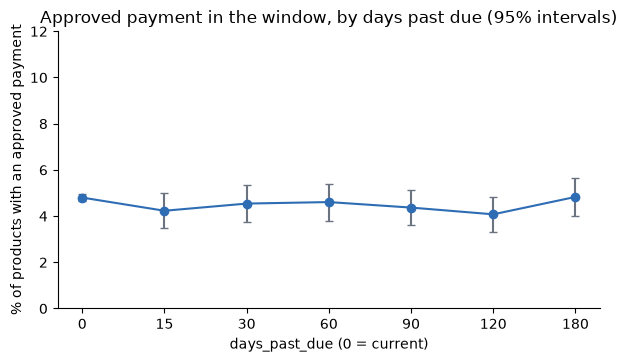

In [12]:
by_days_past_due = active_credit.groupby("days_past_due").agg(
    products=("product_id", "size"),
    any_transaction_pct=("transactions_in_window", lambda s: (s > 0).mean() * 100),
    any_approved_payment_pct=("approved_payments", lambda s: (s > 0).mean() * 100),
    mean_transactions=("transactions_in_window", "mean"),
    median_payment_usd_equivalent_when_paid=("payment_usd_equivalent", lambda s: s[s > 0].median()),
)
by_days_past_due["payment_ci_half_width_pct"] = 1.96 * (
    by_days_past_due["any_approved_payment_pct"] / 100 * (1 - by_days_past_due["any_approved_payment_pct"] / 100)
    / by_days_past_due["products"]
) ** 0.5 * 100
display(by_days_past_due)

fig, ax = plt.subplots(figsize=(7, 3.6))
positions = range(len(by_days_past_due))
ax.errorbar(list(positions), by_days_past_due["any_approved_payment_pct"], yerr=by_days_past_due["payment_ci_half_width_pct"],
            fmt="o-", color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
ax.set_xticks(list(positions))
ax.set_xticklabels(by_days_past_due.index.astype(int).astype(str))
ax.set_xlabel("days_past_due (0 = current)")
ax.set_ylabel("% of products with an approved payment")
ax.set_ylim(0, 12)
ax.set_title("Approved payment in the window, by days past due (95% intervals)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Time to first payment inside the window

The closest thing here to a time-to-payment measure is the day of the **first approved
`Payment`** within the 17 days. It is right-censored (no payment in 17 days means "not yet",
not "never") and, per section 4, a `Payment` is not tied to an obligation, so this is only an
exploratory look at whether delinquent products pay earlier or more often.

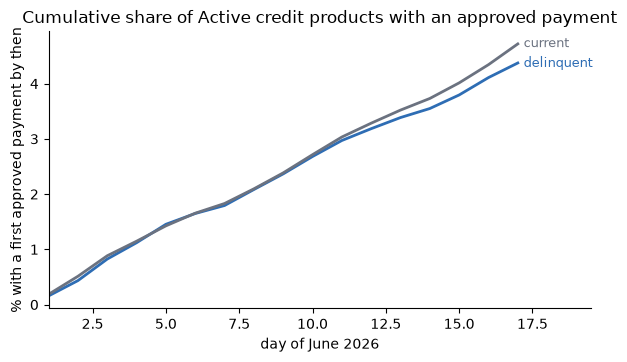

,delinquent,current
day,,
17,4.37,4.72


In [13]:
window_days = pd.date_range(transactions["transaction_date"].min().normalize(), REFERENCE_DATE)
first_payment_day = active_credit["first_payment_date"].dt.normalize()

cumulative_paid_pct = pd.DataFrame({
    label: [(first_payment_day[group_mask] <= day).mean() * 100 for day in window_days]
    for label, group_mask in {
        "delinquent": active_credit["is_delinquent"],
        "current": ~active_credit["is_delinquent"],
    }.items()
}, index=window_days.day)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(cumulative_paid_pct.index, cumulative_paid_pct["delinquent"], color=BAR_COLOR, linewidth=2)
ax.plot(cumulative_paid_pct.index, cumulative_paid_pct["current"], color=MUTED_COLOR, linewidth=2)
ax.text(cumulative_paid_pct.index[-1] + 0.2, cumulative_paid_pct["delinquent"].iloc[-1], "delinquent", va="center", fontsize=9, color=BAR_COLOR)
ax.text(cumulative_paid_pct.index[-1] + 0.2, cumulative_paid_pct["current"].iloc[-1], "current", va="center", fontsize=9, color=MUTED_COLOR)
ax.set_xlim(1, cumulative_paid_pct.index[-1] + 2.5)
ax.set_xlabel("day of June 2026")
ax.set_ylabel("% with a first approved payment by then")
ax.set_title("Cumulative share of Active credit products with an approved payment")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(cumulative_paid_pct.iloc[[-1]].rename_axis("day").round(2))

## 6. Customer level: transactions across all of a customer's products

Delinquency in the customer file is defined per customer (any delinquent credit product).
Customer behaviour is measured over **all** of that customer's products, so deposit-account
activity counts too. Restricted to customers who own at least one `Active` credit product.

,value
customers with an Active credit product,"76,287.00"
delinquent share (%),21.28
with at least one transaction in the window (%),43.43


,feature,segment,rows,delinquent_rate_pct,ci_half_width_pct
0,transactions in window,0,43159,20.51,0.38
1,transactions in window,1,22930,21.71,0.53
2,transactions in window,2,7582,22.75,0.94
3,transactions in window,3,2052,25.78,1.89
4,transactions in window,4+,564,26.24,3.63
5,approved payments,0,68810,21.12,0.30
6,approved payments,1,6962,22.69,0.98
7,approved payments,2,483,24.43,3.83
8,approved payments,3+,32,12.50,11.46
9,declined transactions,0,73985,21.19,0.29


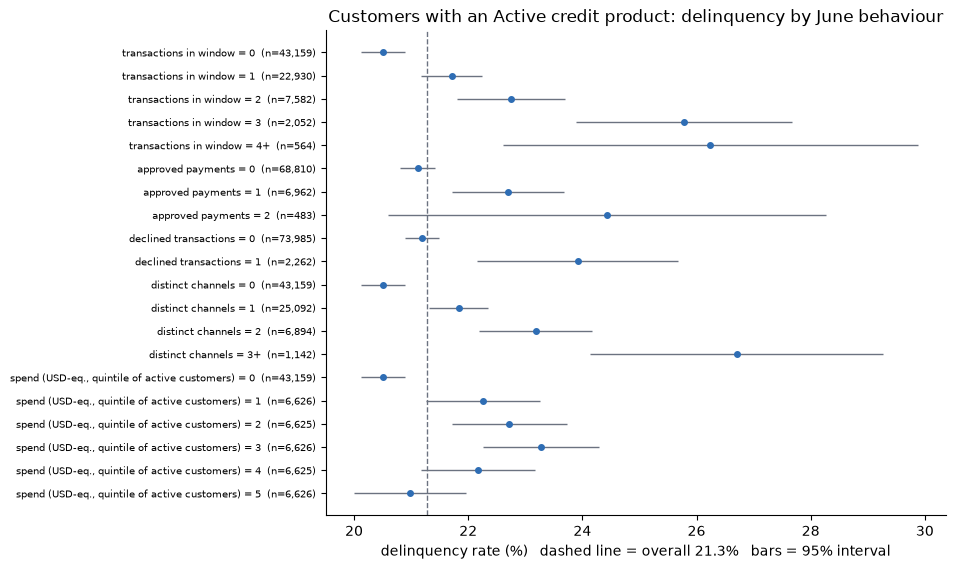

In [14]:
customer_flag = credit.groupby("customer_id").agg(
    is_delinquent_customer=("is_delinquent", "any"),
    has_active_credit=("product_status", lambda s: (s == "Active").any()),
).reset_index()
customer_flag = customer_flag[customer_flag["has_active_credit"]]

customer_activity = transactions.groupby("customer_id").agg(
    transactions_in_window=("transaction_id", "size"),
    approved_payments=("is_approved_payment", "sum"),
    declined=("is_declined", "sum"),
    purchases=("is_purchase", "sum"),
    withdrawals=("is_withdrawal", "sum"),
    distinct_channels=("channel", "nunique"),
    payment_usd_equivalent=("payment_usd_equivalent", "sum"),
    spend_usd_equivalent=("amount_usd_equivalent", "sum"),
)
active_credit_customers = customer_flag.merge(customer_activity, on="customer_id", how="left").fillna(0)
active_credit_customers = active_credit_customers.merge(customers, on="customer_id", how="left")

customer_segments = {
    "transactions in window": bucket_count(active_credit_customers["transactions_in_window"], 4),
    "approved payments": bucket_count(active_credit_customers["approved_payments"], 3),
    "declined transactions": bucket_count(active_credit_customers["declined"], 2),
    "distinct channels": bucket_count(active_credit_customers["distinct_channels"], 3),
    "spend (USD-eq., quintile of active customers)": pd.qcut(
        active_credit_customers["spend_usd_equivalent"].where(active_credit_customers["spend_usd_equivalent"] > 0), 5, labels=False
    ).add(1).fillna(0).astype(int).astype(str),
}
customer_rates = pd.concat(
    [delinquency_rate_by_segment(active_credit_customers, "is_delinquent_customer", values, name)
     for name, values in customer_segments.items()],
    ignore_index=True,
)
customer_base_rate = active_credit_customers["is_delinquent_customer"].mean() * 100
display(pd.Series({
    "customers with an Active credit product": len(active_credit_customers),
    "delinquent share (%)": customer_base_rate,
    "with at least one transaction in the window (%)": (active_credit_customers["transactions_in_window"] > 0).mean() * 100,
}, name="value").to_frame())
display(customer_rates)
plot_rates_against_base(customer_rates, customer_base_rate, "Customers with an Active credit product: delinquency by June behaviour", 300)

### Control for product count (a confound)

More products means more transactions (they are summed over the customer's products) **and** more
chances to have a delinquent credit product. The rise above could therefore be mechanical. First
the link between product count and activity, then the same comparison holding product count fixed.

In [15]:
products_owned = products.groupby("customer_id").size().rename("products_owned")
credit_products_held = credit.groupby("customer_id").size().rename("credit_products_held")
active_credit_customers = active_credit_customers.merge(products_owned, on="customer_id").merge(credit_products_held, on="customer_id")

display(active_credit_customers.groupby("products_owned").agg(
    customers=("customer_id", "size"),
    mean_transactions=("transactions_in_window", "mean"),
    delinquent_pct=("is_delinquent_customer", lambda s: s.mean() * 100),
).head(8))

single_credit = active_credit_customers[active_credit_customers["credit_products_held"] == 1]
most_common_product_count = single_credit["products_owned"].mode().iloc[0]
same_product_count = single_credit[single_credit["products_owned"] == most_common_product_count]
controlled_rates = pd.concat([
    delinquency_rate_by_segment(subset, "is_delinquent_customer", bucket_count(subset["transactions_in_window"], 3), name)
    for name, subset in {
        "exactly 1 credit product": single_credit,
        f"1 credit product and {most_common_product_count} products in total": same_product_count,
    }.items()
], ignore_index=True)
display(controlled_rates)

,customers,mean_transactions,delinquent_pct
products_owned,,,
1,7572,0.21,14.32
2,17018,0.38,17.47
3,20020,0.55,20.61
4,15467,0.72,22.93
5,9197,0.90,26.04
6,4417,1.08,28.46
7,1709,1.29,30.60
8,634,1.32,34.86


,feature,segment,rows,delinquent_rate_pct,ci_half_width_pct
0,exactly 1 credit product,0,28076,14.83,0.42
1,exactly 1 credit product,1,13153,14.28,0.60
2,exactly 1 credit product,2,3803,14.33,1.11
3,exactly 1 credit product,3+,1140,15.18,2.08
4,1 credit product and 2 products in total,0,9093,14.88,0.73
5,1 credit product and 2 products in total,1,3485,14.09,1.16
6,1 credit product and 2 products in total,2,659,15.02,2.73
7,1 credit product and 2 products in total,3+,124,16.94,6.60


In [16]:
numeric_columns = ["transactions_in_window", "approved_payments", "declined", "purchases", "withdrawals",
                   "spend_usd_equivalent", "payment_usd_equivalent"]
worst_days = credit.groupby("customer_id")["days_past_due"].max().rename("worst_days_past_due")
correlation_frame = active_credit_customers.merge(worst_days, on="customer_id")
display(correlation_frame[numeric_columns + ["worst_days_past_due"]].corr(method="spearman")["worst_days_past_due"].drop("worst_days_past_due").to_frame("spearman with worst days_past_due"))

,spearman with worst days_past_due
transactions_in_window,0.03
approved_payments,0.01
declined,0.01
purchases,0.03
withdrawals,0.01
spend_usd_equivalent,0.02
payment_usd_equivalent,0.01


## 7. Reliability checks that affect how far to trust this file

In [17]:
fraud = transactions.groupby("transaction_status")["is_fraud"].agg(fraud_flagged="sum", rows="size")
display(fraud)

home_country = transactions.merge(customers[["customer_id", "country"]], on="customer_id", suffixes=("", "_home"))
domestic_country_names = {"México": "México", "Mexico": "México", "Colombia": "Colombia", "Argentina": "Argentina"}
display(pd.Series({
    "transactions abroad (Brazil, USA, Spain)": (~transactions["transaction_country"].isin(domestic_country_names)).sum(),
    "transactions in a different country than the customer's country of residence":
        (transactions["transaction_country"].map(domestic_country_names) != home_country["country"]).sum(),
    "transactions where the customer's country of residence is known": len(home_country),
}, name="count").to_frame())
display(transactions.groupby("transaction_type")["fraud_score"].agg(missing_pct=lambda s: s.isna().mean() * 100, median="median"))

,fraud_flagged,rows
transaction_status,,
Approved,63,64984
Declined,5,3557
Pending,1,1445
Reversed,0,705


,count
"transactions abroad (Brazil, USA, Spain)",1823
transactions in a different country than the customer's country of residence,3179
transactions where the customer's country of residence is known,70691


,missing_pct,median
transaction_type,,
Adjustment,20.35,14.46
Deposit,20.08,14.90
Payment,20.33,15.03
Purchase,19.66,15.09
Transfer,20.21,15.06
Withdrawal,20.57,14.58


## 8. Conclusions

**Can June transactions be used to determine delinquency? No: on this data they carry no
signal, at any level (product or customer).**

1. **No behavioural difference at product level.** Among 106,596 `Active` credit products
   (14.9% delinquent), the delinquency rate is 14-15% in every segment of activity, declines,
   purchases, withdrawals, recency and payments, and each segment's 95% interval contains the
   overall rate, with one exception: the 179 products with 2+ approved payments (9.5% +/- 4.3).
   Among roughly two dozen segments compared, one marginal outlier in a small group is what chance
   produces, and the much larger 1-payment group (4,882 products) sits at 14.1% +/- 1.0. Only
   18.8% of these products transact at all in the 17 days, and those with 1-2 transactions are
   14.5-15.3% delinquent, the same as the silent 81% (15.0%).
2. **Payment behaviour is the same for delinquent and current products.** An approved `Payment` in
   the window: 4.8% of current products vs 4.1-4.8% at every `days_past_due` level (4.4% vs 4.7%
   cumulative by 17 June). With ~15,900 delinquent products the intervals are about +/-0.3 to
   +/-0.8 points, so a real behavioural gap (delinquent products paying half as often, say) would
   be clearly visible. It is not there. Products in deeper arrears do not pay less.
3. **The customer-level "signal" is an artefact.** The share of delinquent customers rises from
   20.5% (no transactions) to 26.2% (4+), but only because customers with more products transact
   more *and* have more chances to hold a delinquent credit product (delinquent share 14.3% with 1
   product vs 34.9% with 8). Holding product count fixed, the rise disappears: 14.8% / 14.3% /
   14.3% / 15.2% for 0 / 1 / 2 / 3+ transactions among customers with exactly one credit product.
   The Spearman correlations of ~0.01-0.03 with worst `days_past_due` are the same artefact.

**Is there a payment ledger / time-to-payment target in here? No.**

- `Payment` appears on **all eight product types**, including savings, checking, debit cards and
  investments, so it is a generic transaction label, not the repayment of a credit obligation.
- Payment amounts are 50-2,000 USD-equivalent for cards, personal loans and mortgages alike, with
  Spearman correlation to the product balance of -0.04 to 0.01. They are not tied to an
  instalment or an amount due, and there is no due date. Even a perfect "first payment" date would
  not be a time-to-payment for a specific arrear.
- The 17-day window is right-censored (only 4.4% of delinquent `Active` products show an approved
  payment) and ends at the snapshot date, so it is contemporaneous with the delinquency label.

**What the transaction file *does* give us**

- **A data-derived FX rate.** `amount_usd` implies a fixed rate of **350 ARS/USD and 4,000 COP/USD**
  (single rows deviate by under 0.1%, daily medians are identical). At those rates, delinquent
  credit balance is **~181.8 M USD-equivalent (15.1% of the credit balance)**, of which
  **~153.9 M sits on `Active` products** (COP 40.1 M, ARS 27.5 M, USD 86.3 M). This closes the earlier "no FX
  rates" gap, as an explicit assumption from the data. It is not a market rate, and the
  balance is still total exposure, not the overdue amount.
- **Confirmation of who can be worked.** Only `Active` products ever transact. Closed, blocked and
  suspended products have no activity at all.

**Reliability**

- Joins are clean (no orphan products/customers, customer and currency always consistent).
- But: 62,414 of 70,691 transactions (88%) are on products whose `last_transaction_date` in
  `products.csv` is *older* than the June transaction, so that column is not derived from this file.
  204 transactions predate the product's `opening_date` (over the full history, 18.8% of payments do; see
  `transactions_history.ipynb`). Failure rates (~8%) and response codes are identical
  across transaction types, and 63 of 69 fraud-flagged transactions were `Approved`. Together
  with the fixed FX rate and the flat delinquency, this again looks like independently generated data.

**Bottom line.** Adding transactions does not change the verdict: the delinquency label in
`products.csv` behaves as if it were assigned independently of everything we can observe, including
real activity. A time-to-payment model still needs (1) a payments ledger tied to specific
obligations (due date, amount due, payment date) and (2) repeated snapshots of `days_past_due`.
The remaining transaction months (yearly data since 2023) could still be worth a **replication
check** with this same notebook, since a longer window can reveal trends a 17-day window cannot,
but given a flat result across every cut here, the expectation should be low.